In [1]:
import os
import re
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"font.size": 10})
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve
# Neuroimaging
import ants
# PyTorch
import torch

In [2]:
import sys
sys.path.append("../src/")

%load_ext autoreload
%autoreload 2
# Importing our custom module(s)
import ct
import datasets
import losses
import models
import mri
import utils

In [16]:
csv_filename = "ADDF_2024_External_MRimage_800.csv"
dicom_dir = f"/cluster/tufts/hugheslabkp/data_irb_required/ADDF_2024_External_MRimage_800"
labels_df = pd.read_csv(f"{dicom_dir}/{csv_filename}")
print(labels_df.shape)
labels_df.head()

(800, 15)


,STUDY_ID,YearOfScan,SiteID,AgeOfScan,Sex,RaceETH,idWMD,idWMD_Severity,idCBI,idCBI_Location,Stroke,daysfu_str,Dementia,daysfu_dem,withDiffusion
0,STUDY_0010,2009,3,58,M,Asian and Pacific Islander,1,Mild,0,No,0,344,0,344,0
1,STUDY_0016,2014,11,56,F,White,0,No,0,No,0,1954,0,1954,0
2,STUDY_0018,2016,3,64,F,Hispanic,1,Mild,0,No,0,1390,0,1390,0
3,STUDY_0019,2017,3,82,M,Black,1,Moderate,1,Sub-cortical,1,437,0,918,1
4,STUDY_0020,2017,3,53,M,White,1,Mild,0,No,0,803,0,803,0


In [17]:
# CBI: 0.620 +/- 0.034
# WMD: 0.627 +/- 0.070

cbi_experiments_dir = "/cluster/tufts/hugheslab/eharve06/pooling/experiments/KPSC_MRI_800_CBI" 
wmd_experiments_dir = "/cluster/tufts/hugheslab/eharve06/pooling/experiments/KPSC_MRI_800_WMD" 
dataset_dir = "/cluster/tufts/hugheslabkp/data_irb_required/encoded_KPSC_MRI_800/ViT_B_16" 

splits = ["test_site_ids=9_train_site_ids=1_2_3_4_6_7_8_10_11_val_site_ids=5",
          "test_site_ids=1_4_7_10_11_train_site_ids=2_3_5_6_8_val_site_ids=9",
          "test_site_ids=2_6_train_site_ids=3_5_8_9_val_site_ids=1_4_7_10_11",
          "test_site_ids=3_8_train_site_ids=1_4_5_7_9_10_11_val_site_ids=2_6",
          "test_site_ids=5_train_site_ids=1_2_4_6_7_9_10_11_val_site_ids=3_8"]

# CBI model names
cbi_model_names = ["alpha=0.1_criterion=L1_lr=0.001_pooling=mean_seed=1001",
                   "alpha=0.1_criterion=L1_lr=0.0001_pooling=mean_seed=1001",
                   "alpha=0.01_criterion=L1_lr=0.1_pooling=mean_seed=1001",
                   "alpha=0.01_criterion=L1_lr=0.001_pooling=mean_seed=1001",
                   "alpha=1e-06_criterion=L1_lr=0.1_pooling=mean_seed=1001"]
# WMD model names
wmd_model_names = ["alpha=1e-06_criterion=L1_lr=0.1_pooling=mean_seed=1001",
                   "alpha=1.0_criterion=L1_lr=0.1_pooling=mean_seed=1001",
                   "alpha=0.01_criterion=L1_lr=0.1_pooling=mean_seed=1001",
                   "alpha=0.01_criterion=L1_lr=0.1_pooling=mean_seed=1001",
                   "alpha=0.0001_criterion=L1_lr=0.1_pooling=mean_seed=1001"]

In [24]:
from sksurv.metrics import concordance_index_ipcw
from sksurv.util import Surv

num_bootstrap_samples = 500
age_cis = np.full(shape=(len(splits), num_bootstrap_samples), fill_value=np.nan)
cbi_label_cis = np.full(shape=(len(splits), num_bootstrap_samples), fill_value=np.nan)
wmd_label_cis = np.full(shape=(len(splits), num_bootstrap_samples), fill_value=np.nan)
cbi_prob_cis = np.full(shape=(len(splits), num_bootstrap_samples), fill_value=np.nan)
wmd_prob_cis = np.full(shape=(len(splits), num_bootstrap_samples), fill_value=np.nan)
samseg_volume_cis = np.full(shape=(len(splits), num_bootstrap_samples), fill_value=np.nan)

for site_group_id in range(len(splits)):
    
    split = splits[site_group_id]
    cbi_model_name = cbi_model_names[site_group_id]
    wmd_model_name = wmd_model_names[site_group_id]

    test_site_ids, train_site_ids, val_site_ids = [list(map(int, re.findall(r"\d+", re.search(rf"{k}_site_ids=[\d_]+", split).group(0)))) for k in ["test", "train", "val"]]
    
    train_df = labels_df[labels_df["SiteID"].isin(train_site_ids)]
    val_df = labels_df[labels_df["SiteID"].isin(val_site_ids)]
    test_df = labels_df[labels_df["SiteID"].isin(test_site_ids)]

    train_data = torch.load(f"{dataset_dir}/{split}/train.pth")
    val_data = torch.load(f"{dataset_dir}/{split}/val.pth")
    test_data = torch.load(f"{dataset_dir}/{split}/test.pth")
    
    label_index = 0
    train_dataset = datasets.MILDataset(train_data["X"], train_data["lengths"], train_data["y"][:,label_index].reshape(-1, 1))
    val_dataset = datasets.MILDataset(val_data["X"], val_data["lengths"], val_data["y"][:,label_index].reshape(-1, 1))
    test_dataset = datasets.MILDataset(test_data["X"], test_data["lengths"], test_data["y"][:,label_index].reshape(-1, 1))

    batch_size = 64
    train_dataloader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, collate_fn=utils.collate_fn)
    val_dataloader = torch.utils.data.DataLoader(val_dataset, batch_size=batch_size, collate_fn=utils.collate_fn)
    test_dataloader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, collate_fn=utils.collate_fn)

    pooling = "Mean"
    cbi_model = models.ClfPool(in_features=train_data["X"].shape[1], out_features=1, pooling=pooling)

    criterion = losses.ERMLoss(criterion=torch.nn.BCEWithLogitsLoss())
    
    cbi_checkpoint = torch.load(f"{cbi_experiments_dir}/{split}/{cbi_model_name}.pt", map_location=torch.device("cpu"))
    cbi_model.load_state_dict(cbi_checkpoint)

    train_cbi_metrics = utils.evaluate(cbi_model, criterion, train_dataloader)
    val_cbi_metrics = utils.evaluate(cbi_model, criterion, val_dataloader)
    test_cbi_metrics = utils.evaluate(cbi_model, criterion, test_dataloader)

    train_cbi_probs = torch.nn.functional.sigmoid(torch.cat(train_cbi_metrics["logits"])).numpy()
    val_cbi_probs = torch.nn.functional.sigmoid(torch.cat(val_cbi_metrics["logits"])).numpy()
    test_cbi_probs = torch.nn.functional.sigmoid(torch.cat(test_cbi_metrics["logits"])).numpy()

    label_index = 1
    train_dataset = datasets.MILDataset(train_data["X"], train_data["lengths"], train_data["y"][:,label_index].reshape(-1, 1))
    val_dataset = datasets.MILDataset(val_data["X"], val_data["lengths"], val_data["y"][:,label_index].reshape(-1, 1))
    test_dataset = datasets.MILDataset(test_data["X"], test_data["lengths"], test_data["y"][:,label_index].reshape(-1, 1))
    
    batch_size = 64
    train_dataloader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, collate_fn=utils.collate_fn)
    val_dataloader = torch.utils.data.DataLoader(val_dataset, batch_size=batch_size, collate_fn=utils.collate_fn)
    test_dataloader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, collate_fn=utils.collate_fn)

    pooling = "Mean"
    wmd_model = models.ClfPool(in_features=train_data["X"].shape[1], out_features=1, pooling=pooling)

    wmd_checkpoint = torch.load(f"{wmd_experiments_dir}/{split}/{wmd_model_name}.pt", map_location=torch.device("cpu"))
    wmd_model.load_state_dict(wmd_checkpoint)

    train_wmd_metrics = utils.evaluate(wmd_model, criterion, train_dataloader)
    val_wmd_metrics = utils.evaluate(wmd_model, criterion, val_dataloader)
    test_wmd_metrics = utils.evaluate(wmd_model, criterion, test_dataloader)

    train_wmd_probs = torch.nn.functional.sigmoid(torch.cat(train_wmd_metrics["logits"])).numpy()
    val_wmd_probs = torch.nn.functional.sigmoid(torch.cat(val_wmd_metrics["logits"])).numpy()
    test_wmd_probs = torch.nn.functional.sigmoid(torch.cat(test_wmd_metrics["logits"])).numpy()

    train_df["idCBI_prob"] = train_cbi_probs
    train_df["idWMD_prob"] = train_wmd_probs
    val_df["idCBI_prob"] = val_cbi_probs
    val_df["idWMD_prob"] = val_wmd_probs
    test_df["idCBI_prob"] = test_cbi_probs
    test_df["idWMD_prob"] = test_wmd_probs
    
    cols = ["AgeOfScan", "idCBI_prob", "idWMD_prob"]
    print(train_df[cols].std())
    train_mean, train_std = train_df[cols].mean(), train_df[cols].std()
    train_df[cols] = (train_df[cols] - train_mean) / train_std
    val_df[cols] = (val_df[cols] - train_mean) / train_std
    test_df[cols] = (test_df[cols] - train_mean) / train_std
    
    cbi_prob_cph = grid_search(train_df, val_df, duration_col="daysfu_dem", event_col="Dementia", features=["AgeOfScan", "idCBI_prob"])
    wmd_prob_cph = grid_search(train_df, val_df, duration_col="daysfu_dem", event_col="Dementia", features=["AgeOfScan", "idWMD_prob"])

    for j in range(num_bootstrap_samples):

        temp_df = test_df.sample(n=len(test_df), replace=True, random_state=j)
        
        if 1 in temp_df["Dementia"].value_counts().keys():
            if temp_df["Dementia"].value_counts()[1] >= 5:
            
                y_train = Surv.from_dataframe("Dementia", "daysfu_dem", train_df)
                y_val = Surv.from_dataframe("Dementia", "daysfu_dem", val_df)
                y_temp = Surv.from_dataframe("Dementia", "daysfu_dem", temp_df)

                temp_risk = cbi_prob_cph.predict_partial_hazard(temp_df)
                cbi_prob_ci = concordance_index_ipcw(y_train, y_temp, temp_risk)[0]
                temp_risk = wmd_prob_cph.predict_partial_hazard(temp_df)
                wmd_prob_ci = concordance_index_ipcw(y_train, y_temp, temp_risk)[0]

                cbi_prob_cis[site_group_id,j] = cbi_prob_ci
                wmd_prob_cis[site_group_id,j] = wmd_prob_ci
    

/cluster/tufts/hugheslabkp/eharve06/miniconda3/envs/brain-scan-classifiers/lib/python3.8/site-packages/torch/nn/functional.py:1960: UserWarning:

nn.functional.sigmoid is deprecated. Use torch.sigmoid instead.

/cluster/tufts/hugheslabkp/eharve06/miniconda3/envs/brain-scan-classifiers/lib/python3.8/site-packages/torch/nn/functional.py:1960: UserWarning:

nn.functional.sigmoid is deprecated. Use torch.sigmoid instead.

/cluster/tufts/hugheslabkp/eharve06/miniconda3/envs/brain-scan-classifiers/lib/python3.8/site-packages/torch/nn/functional.py:1960: UserWarning:

nn.functional.sigmoid is deprecated. Use torch.sigmoid instead.

/cluster/tufts/hugheslabkp/eharve06/miniconda3/envs/brain-scan-classifiers/lib/python3.8/site-packages/torch/nn/functional.py:1960: UserWarning:

nn.functional.sigmoid is deprecated. Use torch.sigmoid instead.

/cluster/tufts/hugheslabkp/eharve06/miniconda3/envs/brain-scan-classifiers/lib/python3.8/site-packages/torch/nn/functional.py:1960: UserWarning:

nn.functio

AgeOfScan     10.014102
idCBI_prob     0.026364
idWMD_prob     0.264670
dtype: float64


/cluster/tufts/hugheslabkp/eharve06/miniconda3/envs/brain-scan-classifiers/lib/python3.8/site-packages/lifelines/utils/__init__.py:935: UserWarning:

DataFrame Index is not unique, defaulting to incrementing index instead.

/cluster/tufts/hugheslabkp/eharve06/miniconda3/envs/brain-scan-classifiers/lib/python3.8/site-packages/lifelines/utils/__init__.py:935: UserWarning:

DataFrame Index is not unique, defaulting to incrementing index instead.

/cluster/tufts/hugheslabkp/eharve06/miniconda3/envs/brain-scan-classifiers/lib/python3.8/site-packages/lifelines/utils/__init__.py:935: UserWarning:

DataFrame Index is not unique, defaulting to incrementing index instead.

/cluster/tufts/hugheslabkp/eharve06/miniconda3/envs/brain-scan-classifiers/lib/python3.8/site-packages/lifelines/utils/__init__.py:935: UserWarning:

DataFrame Index is not unique, defaulting to incrementing index instead.

/cluster/tufts/hugheslabkp/eharve06/miniconda3/envs/brain-scan-classifiers/lib/python3.8/site-packages/l

/cluster/tufts/hugheslabkp/eharve06/miniconda3/envs/brain-scan-classifiers/lib/python3.8/site-packages/lifelines/utils/__init__.py:935: UserWarning:

DataFrame Index is not unique, defaulting to incrementing index instead.

/cluster/tufts/hugheslabkp/eharve06/miniconda3/envs/brain-scan-classifiers/lib/python3.8/site-packages/lifelines/utils/__init__.py:935: UserWarning:

DataFrame Index is not unique, defaulting to incrementing index instead.

/cluster/tufts/hugheslabkp/eharve06/miniconda3/envs/brain-scan-classifiers/lib/python3.8/site-packages/lifelines/utils/__init__.py:935: UserWarning:

DataFrame Index is not unique, defaulting to incrementing index instead.

/cluster/tufts/hugheslabkp/eharve06/miniconda3/envs/brain-scan-classifiers/lib/python3.8/site-packages/lifelines/utils/__init__.py:935: UserWarning:

DataFrame Index is not unique, defaulting to incrementing index instead.

/cluster/tufts/hugheslabkp/eharve06/miniconda3/envs/brain-scan-classifiers/lib/python3.8/site-packages/l

/cluster/tufts/hugheslabkp/eharve06/miniconda3/envs/brain-scan-classifiers/lib/python3.8/site-packages/lifelines/utils/__init__.py:935: UserWarning:

DataFrame Index is not unique, defaulting to incrementing index instead.

/cluster/tufts/hugheslabkp/eharve06/miniconda3/envs/brain-scan-classifiers/lib/python3.8/site-packages/lifelines/utils/__init__.py:935: UserWarning:

DataFrame Index is not unique, defaulting to incrementing index instead.

/cluster/tufts/hugheslabkp/eharve06/miniconda3/envs/brain-scan-classifiers/lib/python3.8/site-packages/lifelines/utils/__init__.py:935: UserWarning:

DataFrame Index is not unique, defaulting to incrementing index instead.

/cluster/tufts/hugheslabkp/eharve06/miniconda3/envs/brain-scan-classifiers/lib/python3.8/site-packages/lifelines/utils/__init__.py:935: UserWarning:

DataFrame Index is not unique, defaulting to incrementing index instead.

/cluster/tufts/hugheslabkp/eharve06/miniconda3/envs/brain-scan-classifiers/lib/python3.8/site-packages/l

...

/cluster/tufts/hugheslabkp/eharve06/miniconda3/envs/brain-scan-classifiers/lib/python3.8/site-packages/lifelines/utils/__init__.py:935: UserWarning:

DataFrame Index is not unique, defaulting to incrementing index instead.

/cluster/tufts/hugheslabkp/eharve06/miniconda3/envs/brain-scan-classifiers/lib/python3.8/site-packages/lifelines/utils/__init__.py:935: UserWarning:

DataFrame Index is not unique, defaulting to incrementing index instead.

/cluster/tufts/hugheslabkp/eharve06/miniconda3/envs/brain-scan-classifiers/lib/python3.8/site-packages/lifelines/utils/__init__.py:935: UserWarning:

DataFrame Index is not unique, defaulting to incrementing index instead.

/cluster/tufts/hugheslabkp/eharve06/miniconda3/envs/brain-scan-classifiers/lib/python3.8/site-packages/lifelines/utils/__init__.py:935: UserWarning:

DataFrame Index is not unique, defaulting to incrementing index instead.

/cluster/tufts/hugheslabkp/eharve06/miniconda3/envs/brain-scan-classifiers/lib/python3.8/site-packages/l

/cluster/tufts/hugheslabkp/eharve06/miniconda3/envs/brain-scan-classifiers/lib/python3.8/site-packages/lifelines/utils/__init__.py:935: UserWarning:

DataFrame Index is not unique, defaulting to incrementing index instead.

/cluster/tufts/hugheslabkp/eharve06/miniconda3/envs/brain-scan-classifiers/lib/python3.8/site-packages/lifelines/utils/__init__.py:935: UserWarning:

DataFrame Index is not unique, defaulting to incrementing index instead.

/cluster/tufts/hugheslabkp/eharve06/miniconda3/envs/brain-scan-classifiers/lib/python3.8/site-packages/lifelines/utils/__init__.py:935: UserWarning:

DataFrame Index is not unique, defaulting to incrementing index instead.

/cluster/tufts/hugheslabkp/eharve06/miniconda3/envs/brain-scan-classifiers/lib/python3.8/site-packages/lifelines/utils/__init__.py:935: UserWarning:

DataFrame Index is not unique, defaulting to incrementing index instead.

/cluster/tufts/hugheslabkp/eharve06/miniconda3/envs/brain-scan-classifiers/lib/python3.8/site-packages/l

/cluster/tufts/hugheslabkp/eharve06/miniconda3/envs/brain-scan-classifiers/lib/python3.8/site-packages/lifelines/utils/__init__.py:935: UserWarning:

DataFrame Index is not unique, defaulting to incrementing index instead.

/cluster/tufts/hugheslabkp/eharve06/miniconda3/envs/brain-scan-classifiers/lib/python3.8/site-packages/lifelines/utils/__init__.py:935: UserWarning:

DataFrame Index is not unique, defaulting to incrementing index instead.

/cluster/tufts/hugheslabkp/eharve06/miniconda3/envs/brain-scan-classifiers/lib/python3.8/site-packages/lifelines/utils/__init__.py:935: UserWarning:

DataFrame Index is not unique, defaulting to incrementing index instead.

/cluster/tufts/hugheslabkp/eharve06/miniconda3/envs/brain-scan-classifiers/lib/python3.8/site-packages/lifelines/utils/__init__.py:935: UserWarning:

DataFrame Index is not unique, defaulting to incrementing index instead.

/cluster/tufts/hugheslabkp/eharve06/miniconda3/envs/brain-scan-classifiers/lib/python3.8/site-packages/l

/cluster/tufts/hugheslabkp/eharve06/miniconda3/envs/brain-scan-classifiers/lib/python3.8/site-packages/lifelines/utils/__init__.py:935: UserWarning:

DataFrame Index is not unique, defaulting to incrementing index instead.

/cluster/tufts/hugheslabkp/eharve06/miniconda3/envs/brain-scan-classifiers/lib/python3.8/site-packages/lifelines/utils/__init__.py:935: UserWarning:

DataFrame Index is not unique, defaulting to incrementing index instead.

/cluster/tufts/hugheslabkp/eharve06/miniconda3/envs/brain-scan-classifiers/lib/python3.8/site-packages/lifelines/utils/__init__.py:935: UserWarning:

DataFrame Index is not unique, defaulting to incrementing index instead.

/cluster/tufts/hugheslabkp/eharve06/miniconda3/envs/brain-scan-classifiers/lib/python3.8/site-packages/lifelines/utils/__init__.py:935: UserWarning:

DataFrame Index is not unique, defaulting to incrementing index instead.

/cluster/tufts/hugheslabkp/eharve06/miniconda3/envs/brain-scan-classifiers/lib/python3.8/site-packages/l

/cluster/tufts/hugheslabkp/eharve06/miniconda3/envs/brain-scan-classifiers/lib/python3.8/site-packages/lifelines/utils/__init__.py:935: UserWarning:

DataFrame Index is not unique, defaulting to incrementing index instead.

/cluster/tufts/hugheslabkp/eharve06/miniconda3/envs/brain-scan-classifiers/lib/python3.8/site-packages/lifelines/utils/__init__.py:935: UserWarning:

DataFrame Index is not unique, defaulting to incrementing index instead.



In [25]:
cbi_prob_cis_mean = np.nanmean(cbi_prob_cis, axis=0)
wmd_prob_cis_mean = np.nanmean(wmd_prob_cis, axis=0)

print(f"CBI Prob: {np.mean(cbi_prob_cis_mean):.3f} +/- {np.std(cbi_prob_cis_mean):.3f}")
print(f"WMD Prob: {np.mean(wmd_prob_cis_mean):.3f} +/- {np.std(wmd_prob_cis_mean):.3f}")


CBI Prob: 0.829 +/- 0.026
WMD Prob: 0.815 +/- 0.033


In [10]:
import itertools
from lifelines import CoxPHFitter

def grid_search(
    train_df,
    val_df,
    duration_col="daysfu_dem",
    event_col="Dementia",
    features=["AgeOfScan"],
    l1_ratios=[0.0, 1.0],
    penalties=[1e0, 1e-1, 1e-2, 1e-3, 1e-4, 1e-5, 1e-6, 0.0],
):
    
    y_train = Surv.from_dataframe(event_col, duration_col, train_df)
    y_val = Surv.from_dataframe(event_col, duration_col, val_df)
    
    best_cph = None
    best_val_ci = 0.5

    for penalty, l1_ratio in itertools.product(penalties, l1_ratios):

        cph = CoxPHFitter(penalizer=penalty, l1_ratio=l1_ratio)
        fit_options = {"step_size": 0.5, "precision": 1e-07, "max_steps": 1_000}
        cph.fit(train_df[[*features, duration_col, event_col]], duration_col=duration_col, event_col=event_col, fit_options=fit_options)

        train_risk = cph.predict_partial_hazard(train_df)
        val_risk = cph.predict_partial_hazard(val_df)

        train_ci = concordance_index_ipcw(y_train, y_train, train_risk)[0]
        val_ci = concordance_index_ipcw(y_train, y_val, val_risk)[0]

        if val_ci > best_val_ci:
            best_cph = cph
            best_val_ci = val_ci
            
    return best_cph


In [7]:
print(probs_df.shape)
probs_df.to_csv('/cluster/home/eharve06/probs_df.csv', index=False)
probs_df.head()

(800, 5)


,STUDY_ID,test_idCBI_prob,test_idWMD_prob,val_idCBI_prob,val_idWMD_prob
0,STUDY_0010,0.404992,0.802622,0.002462,0.736375
1,STUDY_0016,0.351187,0.584497,0.784508,0.571305
2,STUDY_0018,0.331055,0.801805,0.006949,0.34018
3,STUDY_0019,0.298983,0.92904,0.043644,0.84725
4,STUDY_0020,0.473937,0.952174,0.002356,0.723908


In [11]:
# df.site_group_id, df.idCBI_prob, df.Stroke, and df.daysfu_str
# For each site group, use CBI probability as hazard function to predict stroke and caclulate 
import pandas as pd
from sksurv.metrics import concordance_index_ipcw
from sksurv.util import Surv

df = test_probs_df

# Example: df has columns: ['site_group_id', 'idCBI_prob', 'Stroke', 'daysfu_str']

# Convert data types if necessary
df['Stroke'] = df['Stroke'].astype(bool)
df['daysfu_str'] = pd.to_numeric(df['daysfu_str'], errors='coerce')

# Prepare results container
results = []

# Loop over site groups
for site, group in df.groupby('site_group_id'):
    # Create structured array for survival data
    y = Surv.from_arrays(event=group['Stroke'], time=group['daysfu_str'])
    
    # Predicted risk scores
    y_pred = group['idCBI_prob'].values

    # Compute IPCW concordance index
    cindex, _, _ = concordance_index_ipcw(
        y_true=y, 
        y_pred=y_pred, 
        tau=None  # use full follow-up range
    )
    
    results.append({'site_group_id': site, 'concordance_index_ipcw': cindex})

# Combine into dataframe
cindex_df = pd.DataFrame(results)
print(cindex_df)

TypeError: concordance_index_ipcw() got an unexpected keyword argument 'y_true'

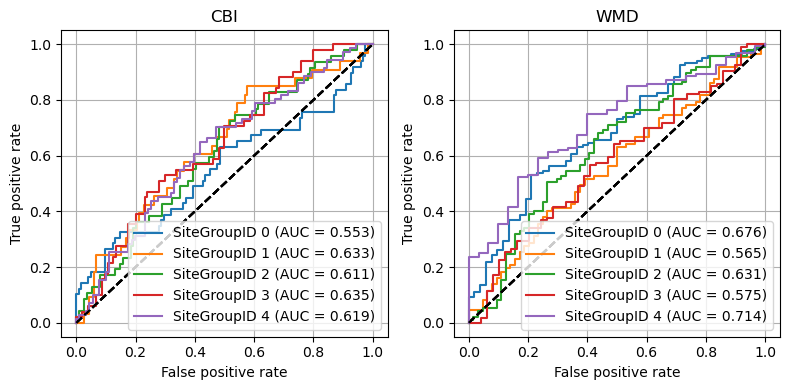

In [13]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

best_thresholds = []

val_probs_df['idCBI_pred'] = 0
test_probs_df['idCBI_pred'] = 0

ncols, nrows = 2, 1
fig, axs = plt.subplots(figsize=(4*ncols,4*nrows), ncols=ncols, nrows=nrows)

for site_group_id in range(len(splits)):
    
    temp_val_df = val_probs_df[val_probs_df.site_group_id == site_group_id]
    temp_test_df = test_probs_df[test_probs_df.site_group_id == site_group_id]

    fpr, tpr, thresholds = roc_curve(temp_val_df.idCBI, temp_val_df.idCBI_prob)
    best_idx = np.argmax(tpr - fpr)
    best_threshold = thresholds[np.argmax(tpr - fpr)]
    best_thresholds.append(best_threshold)
    
    val_probs_df.loc[val_probs_df.site_group_id == site_group_id, "idCBI_pred"] = (
        val_probs_df.loc[val_probs_df.site_group_id == site_group_id, "idCBI_prob"] >= best_threshold
    ).astype(int)
    test_probs_df.loc[test_probs_df.site_group_id == site_group_id, "idCBI_pred"] = (
        test_probs_df.loc[test_probs_df.site_group_id == site_group_id, "idCBI_prob"] >= best_threshold
    ).astype(int)

    fpr, tpr, thresholds = roc_curve(temp_test_df.idCBI, temp_test_df.idCBI_prob)
    auc = roc_auc_score(temp_test_df.idCBI, temp_test_df.idCBI_prob)
    axs[0].plot(fpr, tpr, label=f'SiteGroupID {site_group_id} (AUC = {auc:.3f})')
    axs[0].plot([0, 1], [0, 1], 'k--')
    axs[0].set_xlabel("False positive rate")
    axs[0].set_ylabel("True positive rate")
    axs[0].set_title("CBI")
    axs[0].legend(loc='lower right')
    axs[0].grid()
    
    fpr, tpr, thresholds = roc_curve(temp_val_df.idWMD, temp_val_df.idWMD_prob)
    best_idx = np.argmax(tpr - fpr)
    best_threshold = thresholds[np.argmax(tpr - fpr)]
    best_thresholds.append(best_threshold)
    
    val_probs_df.loc[val_probs_df.site_group_id == site_group_id, "idWMD_pred"] = (
        val_probs_df.loc[val_probs_df.site_group_id == site_group_id, "idWMD_prob"] >= best_threshold
    ).astype(int)
    test_probs_df.loc[test_probs_df.site_group_id == site_group_id, "idWMD_pred"] = (
        test_probs_df.loc[test_probs_df.site_group_id == site_group_id, "idWMD_prob"] >= best_threshold
    ).astype(int)
    
    fpr, tpr, thresholds = roc_curve(temp_test_df.idWMD, temp_test_df.idWMD_prob)
    auc = roc_auc_score(temp_test_df.idWMD, temp_test_df.idWMD_prob)
    axs[1].plot(fpr, tpr, label=f'SiteGroupID {site_group_id} (AUC = {auc:.3f})')
    axs[1].plot([0, 1], [0, 1], 'k--')
    axs[1].set_xlabel("False positive rate")
    axs[1].set_ylabel("True positive rate")
    axs[1].set_title("WMD")
    axs[1].legend(loc='lower right')
    axs[1].grid()

fig.tight_layout()
plt.show()

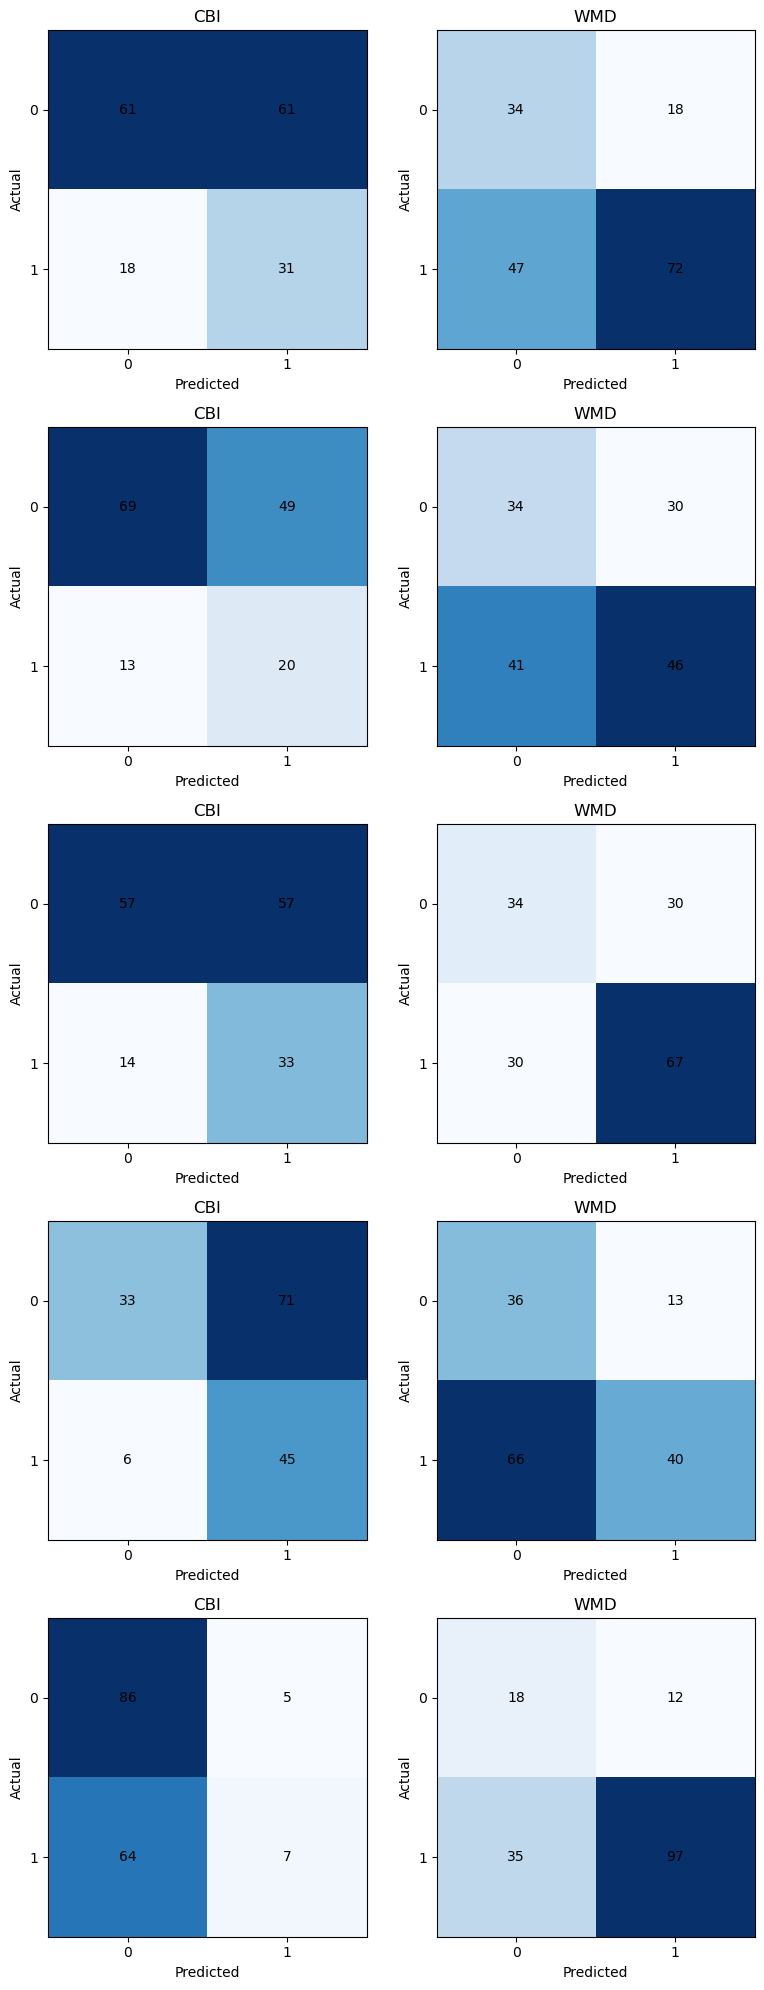

In [16]:
#threshold = 0.5
#test_probs_df["idCBI_pred"] = (test_probs_df["idCBI_prob"] >= threshold).astype(int)
#test_probs_df["idWMD_pred"] = (test_probs_df["idWMD_prob"] >= threshold).astype(int)

ncols, nrows = 2, 5
fig, axs = plt.subplots(figsize=(4*ncols,4*nrows), ncols=ncols, nrows=nrows)

for site_group_id in range(len(splits)):
    
    temp_val_df = val_probs_df[val_probs_df.site_group_id == site_group_id]
    temp_test_df = test_probs_df[test_probs_df.site_group_id == site_group_id]

    cm = confusion_matrix(temp_test_df["idCBI"], temp_test_df["idCBI_pred"])
    im = axs[site_group_id,0].imshow(cm, interpolation="nearest", cmap="Blues")
    #plt.colorbar(im, ax=axs[0])

    for i in range(2):
        for j in range(2):
            axs[site_group_id,0].text(j, i, cm[i, j], ha="center", va="center", color="black")

    axs[site_group_id,0].set_xlabel("Predicted")
    axs[site_group_id,0].set_ylabel("Actual")
    axs[site_group_id,0].set_title("CBI")
    axs[site_group_id,0].set_xticks([0, 1], [0, 1])
    axs[site_group_id,0].set_yticks([0, 1], [0, 1])

    cm = confusion_matrix(temp_test_df["idWMD"], temp_test_df["idWMD_pred"])
    im = axs[site_group_id,1].imshow(cm, interpolation="nearest", cmap="Blues")
    #plt.colorbar(im, ax=axs[1])

    for i in range(2):
        for j in range(2):
            axs[site_group_id,1].text(j, i, cm[i, j], ha="center", va="center", color="black")

    axs[site_group_id,1].set_xlabel("Predicted")
    axs[site_group_id,1].set_ylabel("Actual")
    axs[site_group_id,1].set_title("WMD")
    axs[site_group_id,1].set_xticks([0, 1], [0, 1])
    axs[site_group_id,1].set_yticks([0, 1], [0, 1])

fig.tight_layout()
plt.show()